# CS180H Assignment #3: Baseline GCN on MalNetTiny

**Project**: Mitigating Distribution Shift in Graph-Based Android Malware Classification

**Goal**: Establish a structural baseline (vanilla GCN) for graph classification on
[MalNetTiny](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.MalNetTiny.html)
before adding semantic enrichment in later stages.

**Metrics**: Accuracy, Precision, Recall, F1-score

**Dataset**: MalNetTiny, 5,000 function call graphs from Android APKs across 5 malware types.
- Dataset paper: Freitas et al., [MalNet: A Large-Scale Database for Graph Representation Learning](https://openreview.net/pdf?id=1xDTDk3XPW)
- Reference paper: Tran et al., "Mitigating Distribution Shift in Graph-Based Android Malware Classification via Function Metadata and LLM Embeddings"
- Dataset site: https://www.mal-net.org
- PyG docs: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.MalNetTiny.html

## 1. Setup

In [1]:
# colab already has torch installed, just grab the extras
# pytorch: https://pytorch.org/get-started/locally/
# pyg: https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html
!pip install -q torch-geometric scikit-learn pandas matplotlib tqdm numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 101.9 kB/s eta 0:00:00


In [2]:
import os
import json
import time
import random

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from torch_geometric.datasets import MalNetTiny
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.utils import degree

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}" )

Using device: cuda


## 2. Hyperparameters

In [3]:
# all the knobs in one place
EPOCHS = 50
LR = 0.001
BATCH_SIZE = 64
HIDDEN_DIM = 64
MAX_DEGREE = 128  # for one-hot degree features
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

## 3. Load Dataset

MalNetTiny downloads automatically on first run (~50 MB).

- Docs: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.MalNetTiny.html
- 5,000 graphs, 5 classes, has official train/val/test splits

In [4]:
# MalNetTiny has no node features, so we make one-hot degree vectors
# ref: https://pytorch-geometric.readthedocs.io/en/latest/modules/transforms.html
def add_degree_features(data, max_degree=MAX_DEGREE):
    deg = degree(data.edge_index[0], num_nodes=data.num_nodes, dtype=torch.long)
    deg = deg.clamp( max=max_degree)
    one_hot = torch.zeros(data.num_nodes, max_degree + 1)
    one_hot.scatter_(1, deg.unsqueeze(1), 1)
    data.x = one_hot
    return data

# load with pre_transform so features get cached to disk
# ref: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.MalNetTiny.html
train_ds = MalNetTiny(root="data/", split="train", pre_transform=add_degree_features, force_reload=True)
val_ds = MalNetTiny(root="data/", split="val", pre_transform=add_degree_features)
test_ds = MalNetTiny(root="data/", split="test", pre_transform=add_degree_features)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Features per node: {train_ds.num_features}")
print(f"Number of classes: {train_ds.num_classes}")
print(f"\nSample graph: {train_ds[0]}")

# get class names in the same order PyG assigns integer labels
# PyG reads train -> val -> test and assigns labels by first appearance
# ref: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.MalNetTiny.html
try:
    raw_type_dir = os.path.join("data", "raw", "split_info_tiny", "type")
    y_map = {}
    for split_file in ["train.txt", "val.txt", "test.txt"]:
        with open(os.path.join(raw_type_dir, split_file)) as f:
            for line in f.read().strip().split("\n"):
                mtype = line.split("/")[0]
                y_map.setdefault(mtype, len(y_map))
    CLASS_NAMES = [name for name, _ in sorted(y_map.items(), key=lambda x: x[1])]
except FileNotFoundError:
    # fallback if raw files got cleaned up
    CLASS_NAMES = [f"class_{i}" for i in range(train_ds.num_classes)]

print(f"Classes (label order): {CLASS_NAMES}")

Extracting data/raw/malnet-graphs-tiny.tar.gz
Extracting data/raw/split_info_tiny.zip
Processing...
Done!


Train: 3500 | Val: 500 | Test: 1000
Features per node: 129
Number of classes: 5

Sample graph: Data(edge_index=[2, 3576], y=[1], x=[1679, 129], num_nodes=1679)
Classes (label order): ['adware', 'benign', 'downloader', 'trojan', 'addisplay']


## 4. Dataset Statistics

Total graphs: 5000
Avg nodes: 1522 | Max: 14166 | Min: 5
Avg edges: 2860 | Max: 20096


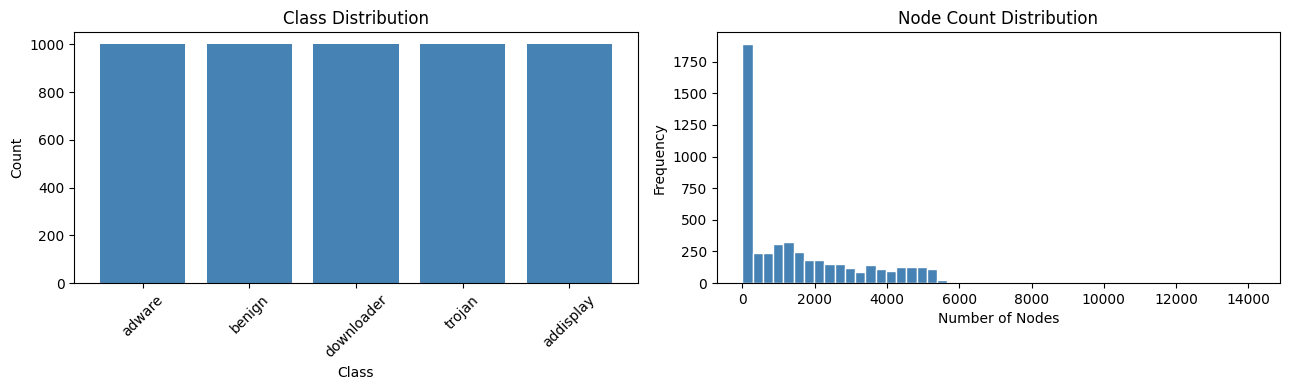

In [5]:
# quick dataset stats
all_ds = MalNetTiny(root="data/", pre_transform=add_degree_features)

node_counts = [all_ds[i].num_nodes for i in range(len(all_ds))]
edge_counts = [all_ds[i].num_edges for i in range( len(all_ds))]
labels = [all_ds[i].y.item() for i in range(len(all_ds))]

print(f"Total graphs: {len(all_ds)}")
print(f"Avg nodes: {np.mean(node_counts):.0f} | Max: {max(node_counts)} | Min: {min(node_counts)}")
print(f"Avg edges: {np.mean(edge_counts):.0f} | Max: {max(edge_counts)}")

# class distribution + node histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

unique, counts = np.unique(labels, return_counts=True)
ax1.bar(CLASS_NAMES, counts, color="steelblue")
ax1.set_xlabel("Class")
ax1.set_ylabel("Count")
ax1.set_title("Class Distribution")
ax1.tick_params(axis="x", rotation=45)

ax2.hist(node_counts, bins=50, color="steelblue", edgecolor="white")
ax2.set_xlabel("Number of Nodes")
ax2.set_ylabel("Frequency")
ax2.set_title("Node Count Distribution")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dataset_overview.png"), dpi=150)
plt.show()

## 5. DataLoaders

In [6]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# sanity check
batch = next(iter(train_loader))
print(f"Batch: {batch}")
print(f"x shape: {batch.x.shape} | y shape: {batch.y.shape}" )

Batch: DataBatch(edge_index=[2, 165486], y=[64], x=[88752, 129], num_nodes=88752, batch=[88752], ptr=[65])
x shape: torch.Size([88752, 129]) | y shape: torch.Size([64])


## 6. Model

Vanilla 2-layer GCN with global mean pooling for graph classification.

- GCNConv: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html
- Graph classification tutorial: https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_gnn.html

In [7]:
# baseline GCN for graph classification
# ref: https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_gnn.html

class BaselineGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = torch.nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        # two gcn layers with relu
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        # pool node embeddings into graph-level embedding
        x = global_mean_pool(x, batch)
        x = self.classifier(x)
        return x

model = BaselineGCN(
    in_channels=train_ds.num_features,
    hidden_channels=HIDDEN_DIM,
    num_classes=train_ds.num_classes,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal params: {total_params:,}")

BaselineGCN(
  (conv1): GCNConv(129, 64)
  (conv2): GCNConv(64, 64)
  (classifier): Linear(in_features=64, out_features=5, bias=True)
)

Total params: 12,805


## 7. Training

In [8]:
def train_one_epoch(model, loader, optimizer, device):
    # single training epoch, returns avg loss
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device):
    # returns (predictions, true_labels) arrays
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        preds = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
    return np.array(all_preds), np.array( all_labels)

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []
val_accs = []
best_val_acc = 0.0
best_state = None

t_start = time.time()
for epoch in tqdm(range(1, EPOCHS + 1), desc="Training"):
    loss = train_one_epoch(model, train_loader, optimizer, device)
    train_losses.append(loss)

    preds, labels = evaluate(model, val_loader, device)
    val_acc = accuracy_score(labels, preds)
    val_accs.append(val_acc)

    # keep track of best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f"  Epoch {epoch:03d} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f}")

train_time = time.time() - t_start
print(f"\nTraining complete in {train_time:.1f}s")
print(f"Best val accuracy: {best_val_acc:.4f}")

# load best model for test evaluation
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

Training:  20%|██        | 10/50 [00:21<01:22,  2.06s/it]

  Epoch 010 | Loss: 0.7651 | Val Acc: 0.7000


Training:  40%|████      | 20/50 [00:42<01:01,  2.04s/it]

  Epoch 020 | Loss: 0.6763 | Val Acc: 0.7520


Training:  60%|██████    | 30/50 [01:02<00:40,  2.05s/it]

  Epoch 030 | Loss: 0.6284 | Val Acc: 0.7680


Training:  80%|████████  | 40/50 [01:23<00:20,  2.06s/it]

  Epoch 040 | Loss: 0.5973 | Val Acc: 0.7500


Training: 100%|██████████| 50/50 [01:43<00:00,  2.07s/it]

  Epoch 050 | Loss: 0.5658 | Val Acc: 0.7540

Training complete in 103.6s
Best val accuracy: 0.7720


## 8. Test Evaluation

- Ref: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

In [10]:
# run on test set
test_preds, test_labels = evaluate(model, test_loader, device)

# sklearn classification report
# ref: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
report_str = classification_report(test_labels, test_preds, target_names=CLASS_NAMES)
report_dict = classification_report(test_labels, test_preds, target_names=CLASS_NAMES, output_dict=True)
test_acc = accuracy_score(test_labels, test_preds)

print(report_str)
print(f"Overall Test Accuracy: {test_acc:.4f}")

              precision    recall  f1-score   support

      adware       0.77      0.88      0.82       200
      benign       0.47      0.59      0.53       200
  downloader       0.99      0.99      0.99       200
      trojan       0.95      0.61      0.75       200
   addisplay       0.71      0.67      0.69       200

    accuracy                           0.75      1000
   macro avg       0.78      0.75      0.76      1000
weighted avg       0.78      0.75      0.76      1000

Overall Test Accuracy: 0.7510


## 9. Results

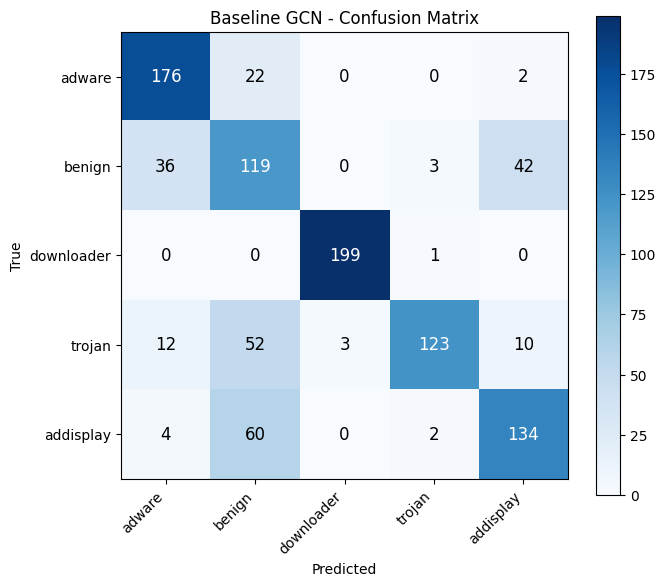

In [11]:
# --- confusion matrix ---
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_title("Baseline GCN - Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_yticklabels(CLASS_NAMES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=12)

fig.colorbar(im)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

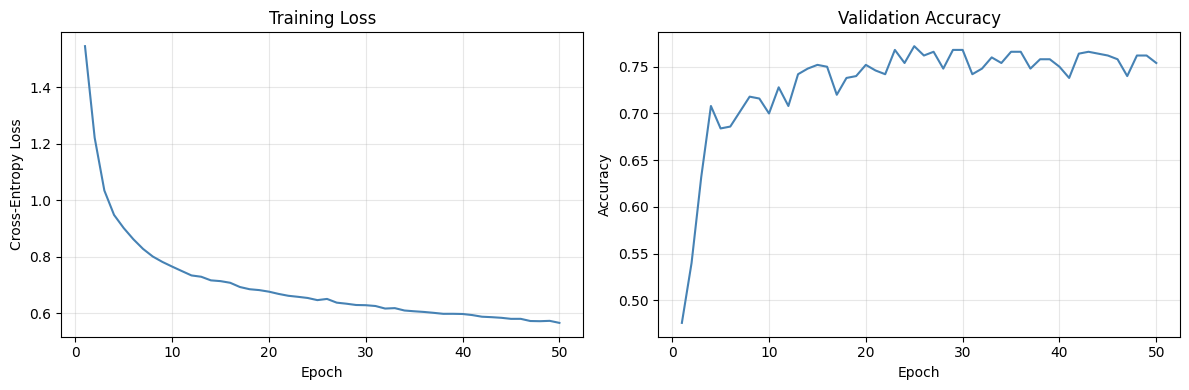

In [12]:
# --- training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, EPOCHS + 1), train_losses, color="steelblue")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Training Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, EPOCHS + 1), val_accs, color="steelblue")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curve.png"), dpi=150)
plt.show()

In [13]:
# --- save metrics table ---
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(os.path.join(RESULTS_DIR, "baseline_results.csv"))
print("Saved: results/baseline_results.csv")
display(report_df)

Saved: results/baseline_results.csv


,precision,recall,f1-score,support
adware,0.771930,0.880,0.822430,200.000
benign,0.470356,0.595,0.525386,200.000
downloader,0.985149,0.995,0.990050,200.000
trojan,0.953488,0.615,0.747720,200.000
addisplay,0.712766,0.670,0.690722,200.000
accuracy,0.751000,0.751,0.751000,0.751
macro avg,0.778738,0.751,0.755262,1000.000
weighted avg,0.778738,0.751,0.755262,1000.000


In [14]:
# --- save full metrics json ---
metrics = {
    "accuracy": round(test_acc, 4),
    "precision_macro": round(report_dict["macro avg"]["precision"], 4),
    "recall_macro": round(report_dict["macro avg"]["recall"], 4),
    "f1_macro": round(report_dict["macro avg"]["f1-score"], 4),
    "per_class": {
        name: {
            "precision": round(report_dict[name]["precision"], 4),
            "recall": round(report_dict[name]["recall"], 4),
            "f1": round(report_dict[name]["f1-score"], 4),
            "support": int(report_dict[name]["support"]),
        }
        for name in CLASS_NAMES
    },
    "training": {
        "epochs": EPOCHS,
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "hidden_dim": HIDDEN_DIM,
        "max_degree": MAX_DEGREE,
        "optimizer": "Adam",
        "train_time_seconds": round(train_time, 1),
        "device": str(device),
    },
}

with open(os.path.join(RESULTS_DIR, "baseline_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved: results/baseline_metrics.json")
print(json.dumps(metrics, indent=2))

Saved: results/baseline_metrics.json
{
  "accuracy": 0.751,
  "precision_macro": 0.7787,
  "recall_macro": 0.751,
  "f1_macro": 0.7553,
  "per_class": {
    "adware": {
      "precision": 0.7719,
      "recall": 0.88,
      "f1": 0.8224,
      "support": 200
    },
    "benign": {
      "precision": 0.4704,
      "recall": 0.595,
      "f1": 0.5254,
      "support": 200
    },
    "downloader": {
      "precision": 0.9851,
      "recall": 0.995,
      "f1": 0.99,
      "support": 200
    },
    "trojan": {
      "precision": 0.9535,
      "recall": 0.615,
      "f1": 0.7477,
      "support": 200
    },
    "addisplay": {
      "precision": 0.7128,
      "recall": 0.67,
      "f1": 0.6907,
      "support": 200
    }
  },
  "training": {
    "epochs": 50,
    "lr": 0.001,
    "batch_size": 64,
    "hidden_dim": 64,
    "max_degree": 128,
    "optimizer": "Adam",
    "train_time_seconds": 103.6,
    "device": "cuda"
  }
}


## Summary

| Metric | Value |
|--------|-------|
| Accuracy | 0.7510 |
| Precision (macro) | 0.7787 |
| Recall (macro) | 0.7510 |
| F1-score (macro) | 0.7553 |

| Class | Precision | Recall | F1 |
|-------|-----------|--------|-----|
| adware | 0.77 | 0.88 | 0.82 |
| benign | 0.47 | 0.60 | 0.53 |
| downloader | 0.99 | 1.00 | 0.99 |
| trojan | 0.95 | 0.62 | 0.75 |
| addisplay | 0.71 | 0.67 | 0.69 |

**Training**: 50 epochs, Adam (lr=0.001), batch size 64, ~104s on T4 GPU. Best val accuracy: 0.7720.

**Outputs saved to `results/`:**
- `baseline_metrics.json`: all metrics in machine-readable format
- `baseline_results.csv`: classification report table
- `confusion_matrix.png`: confusion matrix heatmap
- `training_curve.png`: loss and validation accuracy curves
- `dataset_overview.png`: class distribution and node count histogram